# GDELT EDA

## Part 1. Coverage

Validate whether GDELT DOC API provides sufficient news coverage for target companies, to decide whether GDELT features are worth pursuing.

Two-stage sampling: pilot batch (50) for debugging, then a larger sample for coverage estimation.

In [1]:
import requests
import pandas as pd
import numpy as np
import time
import re
import json
import random
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

import os
from google.cloud import bigquery

from sampling_utils import sample_by_sector_equal, sample_by_sector_proportional

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [2]:
# GDELT DOC API endpoint
GDELT_DOC_API_URL = "https://api.gdeltproject.org/api/v2/doc/doc"

# Query date range: 24 months back from now
    # _END = datetime.utcnow()
    # _START = _END - timedelta(days=730)
    # END_DATETIME = _END.strftime("%Y%m%d%H%M%S")
    # START_DATETIME = _START.strftime("%Y%m%d%H%M%S")
    # print(f"Query window: {START_DATETIME} → {END_DATETIME}")
START_DATETIME = "20240619000000"
END_DATETIME = "20260619000000"

# Request delay
REQUEST_DELAY_SECONDS = 5.5

# Max records per query (DOC API cap: 250)
MAX_RECORDS_PER_QUERY = 50

HEADERS = {
    "User-Agent": "Mozilla/5.0 (research project, Bristol University FYP)"
}

# Data path
DATA_PATH = "../data/UKcompanies_8_sectors_cleaned.csv"
OUTPUT_CSV_PATH = "../output/gdelt_eda_outputs/gkg_sample.csv"
# Output directory
OUTPUT_DIR = Path("../output/gdelt_eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

jupyter nbconvert --to html "00 Data Preparation + EDA/GDELT_EDA.ipynb"

## 1. Data Loading & Sampling

### 1.1 Load company table

In [3]:
df_full = pd.read_csv(DATA_PATH, dtype=str)
print(f"Total rows: {len(df_full)}")
print(f"\nSector distribution:")
print(df_full['primary_sector'].value_counts())

Total rows: 3415689

Sector distribution:
primary_sector
Technology, legal & professional        840587
Real Estate                             799602
Wholesale & Retail                      733641
Fast growth & emerging sector           367454
Healthcare                              241724
Manufacturing                           231184
Public sector, education & charities    158104
Agriculture                              43393
Name: count, dtype: int64


### 1.2 Pilot sample

For debugging only.

In [3]:
PILOT_SAMPLE_SIZE = 50

pilot_sample = sample_by_sector_proportional(
    csv_path=DATA_PATH,
    total_sample_size=PILOT_SAMPLE_SIZE,
)

pilot_sample[['CompanyNumber', 'CompanyName', 'primary_sector']].head(10)

e:\files\Bristol\project\UoB_DS_GroupProject_Team6_LloydsBank\00 Data Preparation + EDA\sampling_utils.py:109: DtypeWarning: Columns (0,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Sampling complete. Target total: 50, Actual: 50
primary_sector
Technology, legal & professional        12
Real Estate                             12
Wholesale & Retail                      11
Fast growth & emerging sector            5
Healthcare                               4
Manufacturing                            3
Public sector, education & charities     2
Agriculture                              1
Name: count, dtype: int64

Original vs sampled:
                                      Original  sampled
primary_sector                                         
Technology, legal & professional      0.246096     0.24
Real Estate                           0.234097     0.24
Wholesale & Retail                    0.214786     0.22
Fast growth & emerging sector         0.107578     0.10
Healthcare                            0.070769     0.08
Manufacturing                         0.067683     0.06
Public sector, education & charities  0.046288     0.04
Agriculture                           0.0

,CompanyNumber,CompanyName,primary_sector
0,1528826,K.P. BIOPLEX LIMITED,"Technology, legal & professional"
1,11677038,AFL LEGAL SERVICES LIMITED,"Technology, legal & professional"
2,12386663,STERLING CONNECTIONS LIMITED,"Technology, legal & professional"
3,17185612,LONGTAIL GROUP LIMITED,"Technology, legal & professional"
4,17005391,VERISAFE CONSULTANCY LTD,"Technology, legal & professional"
5,11706952,APLETREE ACCOUNTANCY SERVICES LTD,"Technology, legal & professional"
6,16183641,CLARK CONSULTANCY SERVICES LTD,"Technology, legal & professional"
7,11070727,CT 11070727 LIMITED,"Technology, legal & professional"
8,SC808989,PJ MELON LIMITED,"Technology, legal & professional"
9,SC762166,BLUE THISTLE PUBLISHING LTD,"Technology, legal & professional"


### 1.3 Company name preprocessing

Strip legal entity suffixes (LIMITED / LTD / PLC etc.) which rarely appear in news text. This is rule-based cleanup, not full entity resolution.

In [4]:
# Common UK company suffixes
SUFFIX_PATTERN = re.compile(
    r'\b(LIMITED|LTD|PLC|LLP|L\.L\.P|L\.L\.C|LLC|UNLIMITED)\b\.?',
    flags=re.IGNORECASE
)


def clean_company_name(name: str) -> str:
    """
    Strip common legal suffixes and extra whitespace/punctuation 
    to produce a company name suitable for searching.
    """
    # Remove company legal suffixes
    name = SUFFIX_PATTERN.sub('', name)

    # Replace '&' with 'and' (or space)
    name = re.sub(r'&', ' ', name) # name = re.sub(r'&', ' and ', name)

    # Remove punctuation and replace with space
    name = re.sub(r'[^\w\s]', ' ', name)

    # Merge multiple consecutive spaces into one, and remove the first and last spaces
    name = re.sub(r'\s+', ' ', name).strip()
    return name.lower()

In [5]:
# Preprocess company names for searching
print(len(pilot_sample))
pilot_sample['search_name'] = pilot_sample['CompanyName'].apply(clean_company_name)
pilot_sample[['CompanyName', 'search_name']].head(10)

50


,CompanyName,search_name
0,K.P. BIOPLEX LIMITED,k p bioplex
1,AFL LEGAL SERVICES LIMITED,afl legal services
2,STERLING CONNECTIONS LIMITED,sterling connections
3,LONGTAIL GROUP LIMITED,longtail group
4,VERISAFE CONSULTANCY LTD,verisafe consultancy
5,APLETREE ACCOUNTANCY SERVICES LTD,apletree accountancy services
6,CLARK CONSULTANCY SERVICES LTD,clark consultancy services
7,CT 11070727 LIMITED,ct 11070727
8,PJ MELON LIMITED,pj melon
9,BLUE THISTLE PUBLISHING LTD,blue thistle publishing


## 2. GDELT DOC API Pilot Test

### 2.1 Single-company test query

Test with a company first to confirm the endpoint works.

In [25]:
def query_gdelt_doc(query_name: str,
                    incorporation_date: str = None, 
                    max_records: int = MAX_RECORDS_PER_QUERY) -> dict:
    """
    Query GDELT DOC API for a single company.

    If incorporation_date is given, start time = max(global START, incorporation date),
    to avoid searching periods before the company existed.
    """
    # start datetime
    start_dt = START_DATETIME
    if incorporation_date:
        inc_dt = pd.to_datetime(incorporation_date).strftime("%Y%m%d%H%M%S")
        if inc_dt > start_dt:
            start_dt = inc_dt

    # Company incorporated after query window ends
    if start_dt >= END_DATETIME:
        return {"articles": [], "skipped": "incorporated_after_window"}

    # Build query string
    params = {
        "query": f'"{query_name}"',
        "mode": "artlist",
        "maxrecords": max_records,
        "format": "json",
        "startdatetime": start_dt,
        "enddatetime": END_DATETIME,
        "sourcelang": "english",
        # "sourcecountry": "UK",
    }

    response = requests.get(GDELT_DOC_API_URL, params=params, headers=HEADERS, timeout=15)

    # Retry once after 429 with longer wait
    if response.status_code == 429:
        print(f"  [429] {query_name}, wait 10s and retry")
        time.sleep(10)
        response = requests.get(GDELT_DOC_API_URL, params=params,
                                headers=HEADERS, timeout=15)
        
    # Retry once after 429 with longer wait
    if response.status_code == 429:
        print(f"  [429] {query_name}, wait 20s and retry")
        time.sleep(20)
        response = requests.get(GDELT_DOC_API_URL, params=params,
                                headers=HEADERS, timeout=15)
        
    # error check
    if response.status_code != 200:
        print(f"[HTTP {response.status_code}] {query_name}")
        return {"articles": []}

    return response.json()

In [26]:
# Test
test = query_gdelt_doc("Greggs")
print(f"fulltext: {len(test.get('articles', []))} articles")

  [429] Greggs, wait 10s and retry
  [429] Greggs, wait 20s and retry
[HTTP 429] Greggs
fulltext: 0 articles


### 2.2 Batch query - pilot sample

In [29]:
def batch_query_companies(sample_df: pd.DataFrame,
                          name_col: str = 'search_name',
                          progress_every: int = 10) -> pd.DataFrame:
    """
    Query GDELT DOC API for each company in sample_df. Adds two columns:
      - article_count: number of articles returned
      - query_status: 'ok' or 'error'
    """
    result_df = sample_df.copy()
    article_counts = []
    statuses = []

    total = len(result_df)
    for i, name in enumerate(result_df[name_col]):
        result = query_gdelt_doc(name)
        articles = result.get('articles', [])
        article_counts.append(len(articles))
        # presence of 'articles' field counts as ok
        statuses.append('ok' if isinstance(articles, list) else 'error')

        if (i + 1) % progress_every == 0:
            print(f"  progress: {i + 1}/{total}")

        time.sleep(REQUEST_DELAY_SECONDS)

    result_df['article_count'] = article_counts
    result_df['query_status'] = statuses
    return result_df

In [ ]:
# Run pilot batch
pilot_results = batch_query_companies(pilot_sample)

print(f"\n Query status counts:")
print(pilot_results['query_status'].value_counts())

print(f"\nArticle count summary:")
print(pilot_results['article_count'].describe())

In [8]:
test = pd.read_csv("../data/UKcompanies_8_sectors_cleaned.csv")

C:\Users\86132\AppData\Local\Temp\ipykernel_3748\191409693.py:1: DtypeWarning: Columns (0,17) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv("../data/UKcompanies_8_sectors_cleaned.csv")


In [14]:
test.head(5)

,CompanyNumber,CompanyName,CompanyStatus,CompanyCategory,CountryOfOrigin,RegAddress_Country,RegAddress_PostTown,RegAddress_PostCode,IncorporationDate,primary_sic_code,sic_codes_all,matched_sectors,has_fast_growth,multi_sic_company,primary_sector,sector_id,Accounts_AccountCategory,Accounts_LastMadeUpDate,Accounts_NextDueDate,Mortgages_NumMortOutstanding,Mortgages_NumMortCharges,has_outstanding_charges,company_age_years,CountryOfOrigin_clean,is_uk_company
0,86,KENTSTONE PROPERTIES LIMITED,Active,Private Limited Company,United Kingdom,NaN,ASHFORD,TN25 6SX,1862-11-27,68209,['68209'],['Real Estate'],False,False,Real Estate,4.0,SMALL,2025-03-31,2026-12-31,19,75,True,163.6,united kingdom,True
1,118,ASHFORD CATTLE MARKET COMPANY LIMITED(THE),Active,Private Limited Company,United Kingdom,NaN,KENT,TN23 1DA,1856-09-25,46110,['46110'],['Wholesale & Retail'],False,False,Wholesale & Retail,3.0,FULL,2025-07-31,2027-04-30,0,2,False,169.7,united kingdom,True
2,121,"ORIENTAL GAS COMPANY, LIMITED(THE)",Active,Private Limited Company,United Kingdom,NaN,LONDON,EC4A 2EA,1856-09-26,70100,['70100'],"['Technology, legal & professional']",False,False,"Technology, legal & professional",5.0,TOTAL EXEMPTION FULL,2025-06-30,2027-03-31,2,4,True,169.7,united kingdom,True
3,140,N & C BUILDING PRODUCTS LIMITED,Active,Private Limited Company,United Kingdom,NaN,ROMFORD,RM8 1SP,1856-09-30,20301,"['20301', '23690', '46730']","['Manufacturing', 'Wholesale & Retail']",False,True,Manufacturing,2.0,FULL,2024-12-31,2026-09-30,1,5,True,169.7,united kingdom,True
4,295,METHODIST NEWSPAPER COMPANY LIMITED,Active,Private Limited Company,United Kingdom,ENGLAND,HUNSTANTON,PE36 6JG,1863-03-13,58130,['58130'],"['Technology, legal & professional']",False,False,"Technology, legal & professional",5.0,TOTAL EXEMPTION FULL,2026-03-22,2027-12-22,1,2,True,163.3,united kingdom,True


## 3. GKG

DOC API has heavy rate limiting and only returns article metadata. GKG already provides pre-computed entity extraction, sentiment, and theme labels — and is the data source we will use for feature engineering. From here onward, GKG is the main path.

In [6]:
import os
from google.cloud import bigquery

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../key/lloyds-gdelt-500117-a700e8484a10.json"

client = bigquery.Client(project="lloyds-gdelt-500117")

In [7]:
# GKG query window
    # GKG_END = datetime.utcnow()
GKG_END = datetime.strptime("2026-06-20", "%Y-%m-%d")
GKG_START = GKG_END - timedelta(days=90)
GKG_START_STR = GKG_START.strftime("%Y-%m-%d")
GKG_END_STR = GKG_END.strftime("%Y-%m-%d")
print(f"GKG window: {GKG_START_STR} - {GKG_END_STR}")

GKG window: 2026-03-22 - 2026-06-20


### 3.1 Single-company GKG query

EDA window: last 3 months.

In [9]:
def query_gkg_single(company_name: str,
                    start_date: str = GKG_START_STR,
                    end_date: str = GKG_END_STR,
                    incorporation_date: str = None,
                    uk_only: bool = False,
                    limit: int = 200) -> pd.DataFrame:
    """
    Query GKG for articles mentioning a single company.
    
    If incorporation_date is given, query start = max(start_date, incorporation date).

    uk_only=True restricts to .uk source domains.(Filted in CompaniesHouse)
    """
    # handle incorporation date
    actual_start = start_date
    if incorporation_date:
        inc = pd.to_datetime(incorporation_date).strftime("%Y-%m-%d")
        if inc > actual_start:
            actual_start = inc
    if actual_start >= end_date:
        return pd.DataFrame()

    # Lowercase for case-insensitive matching
    pattern = company_name.lower()

    uk_filter = "AND SourceCommonName LIKE '%.uk'" if uk_only else ""

    sql = f"""
    SELECT
      DATE,
      DocumentIdentifier,
      V2Organizations,
      V2Tone,
      V2Themes,
      SourceCommonName,
      V2Locations
    FROM `gdelt-bq.gdeltv2.gkg_partitioned`
    WHERE _PARTITIONTIME BETWEEN TIMESTAMP('{actual_start}') AND TIMESTAMP('{end_date}')
      AND REGEXP_CONTAINS(LOWER(V2Organizations), @pattern)
      {uk_filter}
    LIMIT {limit}
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[bigquery.ScalarQueryParameter("pattern", "STRING", pattern)]
    )
    return client.query(sql, job_config=job_config).to_dataframe()

In [31]:
# Test
sample_company = query_gkg_single("greggs", limit=5)
print(f" Returned: {len(sample_company)} rows")

e:\Anaconda\envs\text_analytics\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 Returned: 5 rows


In [32]:
sample_company[['DATE','DocumentIdentifier']].head()

,DATE,DocumentIdentifier
0,20260531091500,https://www.mirror.co.uk/travel/stunning-seasi...
1,20260426220000,https://www.thetimes.com/uk/crime/article/shop...
2,20260606023000,https://www.dailypolitical.com/2026/06/05/greg...
3,20260330014500,https://www.chroniclelive.co.uk/news/north-eas...
4,20260518134500,https://leftfootforward.org/2026/05/reform-cou...


### 3.2 Batch query strategy

We do not query each company separately (each query scans the partition independently, scan size accumulates). Instead, combine all company names into one regex pattern, run a single SQL query, and aggregate per-company locally in pandas.

#### 3.2.1 Combine the company names

In [8]:
def build_company_pattern(names: list):
    """
    Combine a list of company names into a single regex for V2Organizations matching.

    Each name is regex-escaped, then joined by |. The pattern matches case-insensitively
    (caller is responsible for LOWER()-ing V2Organizations).
    """
    # escaped = [re.escape(n.lower().strip()) for n in names if n and n.strip()]
    valid_names = [n.lower().strip() for n in names if n and n.strip()]
    escaped = [re.escape(n) for n in valid_names]
    pattern = r'\b(' + '|'.join(escaped) + r')\b'
    # use \b boundary to avoid substring matches
    return pattern, valid_names

In [9]:
# Some company names may be misescaped. Check before query.
def company_pattern_check(pilot_names, valid_names):
    print(f"Input: {len(pilot_names)}")
    print(f"In pattern: {len(valid_names)}")
    print(f"Skipped:")
    for n in pilot_names:
        if not n or not n.strip():
            print(f"  - empty/blank name")

In [10]:
pattern, valid_names = build_company_pattern(pilot_sample['search_name'])
company_pattern_check(pilot_sample['search_name'], valid_names)

Input: 50
In pattern: 50
Skipped:


#### 3.2.2 Batch query Functions

In [13]:
def query_gkg_batch_dryrun(company_names: list,
                           start_date: str = GKG_START_STR,
                           end_date: str = GKG_END_STR,
                           uk_only: bool = False) -> float:
    """
    Dry run only — returns estimated scan size in GB without executing the query.
    """
    #pattern = build_company_pattern(company_names)
    pattern, valid_names = build_company_pattern(company_names)
    if len(valid_names) < len(company_names):
        print(f"Input: {len(company_names)}, In pattern: {len(valid_names)}")

    uk_filter = "AND SourceCommonName LIKE '%.uk'" if uk_only else ""

    sql = f"""
    SELECT
      DATE, 
      DocumentIdentifier, 
      V2Counts,
      V2Themes, 
      V2Organizations,
      V2Tone, 
      Amounts
    FROM `gdelt-bq.gdeltv2.gkg_partitioned`
    WHERE _PARTITIONTIME BETWEEN TIMESTAMP('{start_date}') AND TIMESTAMP('{end_date}')
      AND REGEXP_CONTAINS(LOWER(V2Organizations), @pattern)
      {uk_filter}
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[bigquery.ScalarQueryParameter("pattern", "STRING", pattern)],
        dry_run=True,
        use_query_cache=False,
    )
    job = client.query(sql, job_config=job_config)
    gb = job.total_bytes_processed / 1e9
    print(f"Estimated scan: {gb:.2f} GB")
    return gb


def query_gkg_batch(company_names: list,
                    start_date: str = GKG_START_STR,
                    end_date: str = GKG_END_STR,
                    uk_only: bool = False,
                    output_path: str = OUTPUT_CSV_PATH) -> pd.DataFrame:
    """
    Execute the GKG batch query. Run query_gkg_batch_dryrun first to confirm scan size.
    """
    pattern, _ = build_company_pattern(company_names)
    uk_filter = "AND SourceCommonName LIKE '%.uk'" if uk_only else ""

    sql = f"""
    SELECT
      DATE, 
      DocumentIdentifier, 
      V2Counts, 
      V2Themes, 
      V2Organizations,
      V2Tone, 
      Amounts
    FROM `gdelt-bq.gdeltv2.gkg_partitioned`
    WHERE _PARTITIONTIME BETWEEN TIMESTAMP('{start_date}') AND TIMESTAMP('{end_date}')
      AND REGEXP_CONTAINS(LOWER(V2Organizations), @pattern)
      {uk_filter}
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[bigquery.ScalarQueryParameter("pattern", "STRING", pattern)]
    )

    query_job = client.query(sql, job_config=job_config)
    rows = query_job.result()
    is_first_chunk = True
    for chunk in rows.to_dataframe_iterable():
        chunk.to_csv(output_path, mode='a', index=False, header=is_first_chunk)
        is_first_chunk = False
        print(f"A chunk of data have been safely written to the hard drive: {output_path}")
      
    print("finished")
    # return client.query(sql, job_config=job_config).to_dataframe()

### 3.3  Run the batch query

First validate with the 50-company pilot_sample, then scale up to the main sample.

In [14]:
# dry run to check scan size
query_gkg_batch_dryrun(pilot_sample['search_name'])

Estimated scan: 39.31 GB


39.314118657

In [ ]:
# after confirming scan size, run the query
query_gkg_batch(pilot_sample['search_name'])

In [15]:
pilot_gkg = pd.read_csv(OUTPUT_CSV_PATH)
pilot_gkg.head()

,DATE,DocumentIdentifier,V2Counts,V2Themes,V2Organizations,V2Tone,Amounts
0,20260525233000,https://www.thejournal.ie/scottish-national-pa...,NaN,NaN,"Hasbro,2825;Shop Airbus Of Airbus Operations,2...","-1.54277699859748,2.24403927068724,3.786816269...","2,toilet seats for nearly,1428;3,designer mani..."
1,20260531031500,https://www.afr.com/chanticleer/leverage-luck-...,NaN,"GENERAL_HEALTH,250;MEDICAL,250;TAX_ECON_PRICE,...","Estia Health,250","0,2.97029702970297,2.97029702970297,5.94059405...",NaN
2,20260525003000,https://fnarena.com/index.php/2026/05/25/the-m...,NaN,"GENERAL_HEALTH,19402;WB_713_PUBLIC_FINANCE,771...","Google,15564;Xinhua,16389;Jardine Matheson,196...","0.553319919517103,2.89235412474849,2.339034205...","26,points,963;12,months,1179;25,basis points,1..."
3,20260527204500,https://www.fwweekly.com/2026/05/25/summer-sum...,NaN,NaN,"Team Sport,3068;Maple Branch,4024","2.52206809583859,4.03530895334174,1.5132408575...","10,kids through college,1138;5,international d..."
4,20260529021500,https://www.australianageingagenda.com.au/noti...,NaN,"TAX_ETHNICITY_AUSTRALIANS,1461;TAX_ETHNICITY_A...","Aura Holdings,2379;Estia Health,85;Estia Healt...","4.71698113207547,4.71698113207547,0,4.71698113...","838000000,dollars ,339;73,homes,427;7,homes,47..."


#### 3.3.2 Reverse mapping

One article can match multiple companies (V2Organizations contains many organisations). 

For each article, scan V2Organizations for which queried companies appear, producing a long table:

[company, url, date, tone, themes, ...].

In [16]:

def map_articles_to_companies(gkg_df, company_names):
    """
    Map GKG articles to queried companies via V2Organizations.
    """
    name_set = [n.lower().strip() for n in company_names if n and n.strip()]
    # Pre-compile a boundary regex for each company
    patterns = {n: re.compile(r'\b' + re.escape(n) + r'\b') for n in name_set}

    rows = []
    for _, art in gkg_df.iterrows():
        orgs_lower = str(art['V2Organizations']).lower()
        for name, pat in patterns.items():
            if pat.search(orgs_lower):
                rows.append({
                    'company_search_name': name,
                    'DATE': art['DATE'],
                    'DocumentIdentifier': art['DocumentIdentifier'],
                    'V2Counts': art['V2Counts'],
                    'V2Themes': art['V2Themes'],
                    'V2Organizations': art['V2Organizations'],
                    'v2tone': art['V2Tone'],
                    'Amounts': art['Amounts'],
                })
    return pd.DataFrame(rows)

In [12]:
import ahocorasick

def map_articles_to_companies_fast(gkg_df: pd.DataFrame,
                               company_names: list) -> pd.DataFrame:
    """
    Map articles to companies via Aho-Corasick automaton.
    """
    # 1. build automaton
    A = ahocorasick.Automaton()
    valid_count = 0
    for name in company_names:
        if name and isinstance(name, str):
            cleaned = name.lower().strip()
            if cleaned:
                A.add_word(cleaned, cleaned)
                valid_count += 1

    if valid_count == 0:
        return pd.DataFrame()

    A.make_automaton()

    # 2. scan each article
    cols = ['V2Organizations', 'DATE', 'DocumentIdentifier',
            'V2Counts', 'V2Themes', 'V2Tone', 'Amounts']
    arrays = {c: gkg_df[c].values for c in cols}
    n = len(gkg_df)

    rows = []
    for i in range(n):
        orgs_raw = arrays['V2Organizations'][i]
        if not isinstance(orgs_raw, str):
            continue

        orgs_lower = orgs_raw.lower()
        length = len(orgs_lower)
        matched = set()

        for end_index, name in A.iter(orgs_lower):
            start_index = end_index - len(name) + 1
            left_ok = (start_index == 0) or not orgs_lower[start_index - 1].isalnum()
            right_ok = (end_index == length - 1) or not orgs_lower[end_index + 1].isalnum()

            if left_ok and right_ok:
                matched.add(name)

        for comp in matched:
            rows.append({
                'company_search_name': comp,
                'DATE': arrays['DATE'][i],
                'DocumentIdentifier': arrays['DocumentIdentifier'][i],
                'V2Counts': arrays['V2Counts'][i],
                'V2Themes': arrays['V2Themes'][i],
                'V2Organizations': orgs_raw,
                'V2Tone': arrays['V2Tone'][i],
                'Amounts': arrays['Amounts'][i],
            })

    return pd.DataFrame(rows)

In [17]:
#pilot_mapped = map_articles_to_companies(pilot_gkg, pilot_sample['search_name'])
pilot_mapped = map_articles_to_companies_fast(pilot_gkg, pilot_sample['search_name'])
print(f"Number of companies: {len(pilot_sample)}")
print(f"Rows after mapping: {len(pilot_mapped)}")
print(f"Distinct matched companies: {pilot_mapped['company_search_name'].nunique()}")

Number of companies: 50
Rows after mapping: 101
Distinct matched companies: 3


In [18]:
pilot_mapped.head(10)

,company_search_name,DATE,DocumentIdentifier,V2Counts,V2Themes,V2Organizations,V2Tone,Amounts
0,airbus operations,20260525233000,https://www.thejournal.ie/scottish-national-pa...,NaN,NaN,"Hasbro,2825;Shop Airbus Of Airbus Operations,2...","-1.54277699859748,2.24403927068724,3.786816269...","2,toilet seats for nearly,1428;3,designer mani..."
1,estia,20260531031500,https://www.afr.com/chanticleer/leverage-luck-...,NaN,"GENERAL_HEALTH,250;MEDICAL,250;TAX_ECON_PRICE,...","Estia Health,250","0,2.97029702970297,2.97029702970297,5.94059405...",NaN
2,estia,20260525003000,https://fnarena.com/index.php/2026/05/25/the-m...,NaN,"GENERAL_HEALTH,19402;WB_713_PUBLIC_FINANCE,771...","Google,15564;Xinhua,16389;Jardine Matheson,196...","0.553319919517103,2.89235412474849,2.339034205...","26,points,963;12,months,1179;25,basis points,1..."
3,maple branch,20260527204500,https://www.fwweekly.com/2026/05/25/summer-sum...,NaN,NaN,"Team Sport,3068;Maple Branch,4024","2.52206809583859,4.03530895334174,1.5132408575...","10,kids through college,1138;5,international d..."
4,estia,20260529021500,https://www.australianageingagenda.com.au/noti...,NaN,"TAX_ETHNICITY_AUSTRALIANS,1461;TAX_ETHNICITY_A...","Aura Holdings,2379;Estia Health,85;Estia Healt...","4.71698113207547,4.71698113207547,0,4.71698113...","838000000,dollars ,339;73,homes,427;7,homes,47..."
5,estia,20260609070000,https://www.miragenews.com/minterellison-guide...,NaN,"TRIAL,873;TRIAL,893;TRIAL,915;TRIAL,940;TRIAL,...","Aura Holdings,203;Estia Health,256;Axight Capi...","1.85185185185185,3.24074074074074,1.3888888888...","90,homes across New South,279;"
6,estia,20260518010000,https://www.itnews.com.au/news/estia-health-dr...,NaN,"GENERAL_HEALTH,67;GENERAL_HEALTH,202;GENERAL_H...","Estia Health,67;Estia Health,202;Estia Health,...","4.87804878048781,6.82926829268293,1.9512195121...","100,aged care homes,306;3,dots so,3159;"
7,maple branch,20260520220000,https://www.fwweekly.com/2026/05/20/sippin-thr...,NaN,"TAX_ETHNICITY_ENGLISH,505;TAX_WORLDLANGUAGES_E...","Maple Branch,235;Maple Branch,782;Maple Branch...","5.94315245478036,7.23514211886305,1.2919896640...","5,medals,528;25,awards,595;24,handcrafted beer..."
8,maple branch,20260528173000,https://www.sozcu.com.tr/goz-agrisi-sandi-kafa...,NaN,"TAX_FNCACT_DOCTOR,982;GENERAL_HEALTH,643;GENER...","Maple Branch,1369","-4.62046204620462,1.98019801980198,6.600660066...",NaN
9,estia,20260528010000,https://fnarena.com/index.php/2026/05/28/the-o...,NaN,"TAX_FNCACT_AUTHOR,13613;ECON_INTEREST_RATES,13...","Dow Jones,531;Dow Jones,2821;Nvidia,1751;Nvidi...","0.157542339503741,2.12682158330051,1.969279243...","4,straight day,1533;7,sessions,2059;2,decimal ..."


In [19]:
hit_names = pilot_mapped['company_search_name'].value_counts()
print(hit_names)

company_search_name
airbus operations    81
estia                14
maple branch          6
Name: count, dtype: int64


In [22]:
all_search_names = set(pilot_sample['search_name'].str.lower().str.strip())
missed = all_search_names - set(pilot_mapped['company_search_name'].unique())
print(f"\nMissed ({len(missed)}):")
for n in list(missed):
    print(f"  {n}")


Missed (47):
  rykova psychotherapy practice
  dayal health
  littlediode
  powr life
  k p bioplex
  ideatel
  college place management company strand road
  clarbum
  ch17
  amethystnova
  vostel
  blue thistle publishing
  chase cycles hampshire
  em truck paint
  hebrews 13
  mac tree services
  ultraclean valets
  teme valley carpets
  nomad growth systems
  clark consultancy services
  longtail group
  roost renovations
  orange psychology
  rational vaccines uk
  chancery estates
  kenton properties uk
  apletree accountancy services
  rutland house leicester management company
  sbm investment properties
  business bosses
  leapfrog real estate
  douglas hr consulting
  tj autos sw
  sterling connections
  verisafe consultancy
  wilcowan holdings 2024
  the book shop on the square
  priory cc165
  cars to sale
  display by design
  ct 11070727
  legacy vaper
  afl legal services
  flatmates nw
  48 50 hythe road brighton
  holmes court garstang
  pj melon


Attempt to retrieve previously unqueried companies using 'AllNames'

In [40]:
def query_gkg_single_AllNames(company_name: str,
                    start_date: str = GKG_START_STR,
                    end_date: str = GKG_END_STR,
                    incorporation_date: str = None,
                    uk_only: bool = False,
                    limit: int = 200) -> pd.DataFrame:
    """
    Query GKG for articles mentioning a single company.
    
    If incorporation_date is given, query start = max(start_date, incorporation date).

    uk_only=True restricts to .uk source domains.(Filted in CompaniesHouse)
    """
    # handle incorporation date
    actual_start = start_date
    if incorporation_date:
        inc = pd.to_datetime(incorporation_date).strftime("%Y-%m-%d")
        if inc > actual_start:
            actual_start = inc
    if actual_start >= end_date:
        return pd.DataFrame()

    # Lowercase for case-insensitive matching
    pattern = company_name.lower()

    uk_filter = "AND SourceCommonName LIKE '%.uk'" if uk_only else ""

    sql = f"""
    SELECT
      DATE,
      DocumentIdentifier,
      AllNames,
    FROM `gdelt-bq.gdeltv2.gkg_partitioned`
    WHERE _PARTITIONTIME BETWEEN TIMESTAMP('{actual_start}') AND TIMESTAMP('{end_date}')
      AND REGEXP_CONTAINS(LOWER(AllNames), @pattern)
      {uk_filter}
    LIMIT {limit}
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[bigquery.ScalarQueryParameter("pattern", "STRING", pattern)]
    )
    return client.query(sql, job_config=job_config).to_dataframe()

In [41]:
# Test
test_company = query_gkg_single_AllNames("mac tree services", limit=5)
print(f" Returned: {len(test_company)} rows")

e:\Anaconda\envs\text_analytics\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 Returned: 0 rows


In [ ]:
test_company[['DATE','DocumentIdentifier']].head()

### 3.4 Scale up to the main sample

#### 3.4.1  Main sample(10000) batch query

In [23]:
MAIN_SAMPLE_SIZE = 10000
OUTPUT_CSV_PATH_10000 = "../output/gdelt_eda_outputs/gkg_sample_10000.csv"

In [24]:
main_sample = sample_by_sector_proportional(
    csv_path=DATA_PATH,
    total_sample_size=MAIN_SAMPLE_SIZE,
)
main_sample['search_name'] = main_sample['CompanyName'].apply(clean_company_name)

main_names = main_sample['search_name'].dropna().unique().tolist()
print(f"\nMain sample size: {len(main_names)}")

e:\files\Bristol\project\UoB_DS_GroupProject_Team6_LloydsBank\00 Data Preparation + EDA\sampling_utils.py:109: DtypeWarning: Columns (0,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Sampling complete. Target total: 10000, Actual: 10001
primary_sector
Technology, legal & professional        2461
Real Estate                             2341
Wholesale & Retail                      2148
Fast growth & emerging sector           1076
Healthcare                               708
Manufacturing                            677
Public sector, education & charities     463
Agriculture                              127
Name: count, dtype: int64

Original vs sampled:
                                      Original   sampled
primary_sector                                          
Technology, legal & professional      0.246096  0.246075
Real Estate                           0.234097  0.234077
Wholesale & Retail                    0.214786  0.214779
Fast growth & emerging sector         0.107578  0.107589
Healthcare                            0.070769  0.070793
Manufacturing                         0.067683  0.067693
Public sector, education & charities  0.046288  0.046295
Agricultur

In [32]:
main_sample.to_csv("../output/gdelt_eda_outputs/main_sample_10000.csv")

In [25]:
# dry run to check scan size
query_gkg_batch_dryrun(main_names)

Estimated scan: 39.31 GB


39.314118657

In [26]:
# after confirming scan size, run the query
query_gkg_batch(main_names, output_path=OUTPUT_CSV_PATH_10000)

A chunk of data have been safely written to the hard drive: ../output/gdelt_eda_outputs/gkg_sample_10000.csv
A chunk of data have been safely written to the hard drive: ../output/gdelt_eda_outputs/gkg_sample_10000.csv
A chunk of data have been safely written to the hard drive: ../output/gdelt_eda_outputs/gkg_sample_10000.csv
A chunk of data have been safely written to the hard drive: ../output/gdelt_eda_outputs/gkg_sample_10000.csv
finished


In [27]:
main_gkg = pd.read_csv(OUTPUT_CSV_PATH_10000)
main_gkg.head()

,DATE,DocumentIdentifier,V2Counts,V2Themes,V2Organizations,V2Tone,Amounts
0,20260511013000,https://www.ky3.com/2026/05/11/first-alert-wea...,NaN,"CRISISLEX_O01_WEATHER,1261;EPU_UNCERTAINTY,106...","First Alert Weather Team,2152","-2.13270142180095,2.13270142180095,4.265402843...","2,weather systems,1440;"
1,20260426234500,https://ekonomi.bisnis.com/read/20260427/44/19...,NaN,"EPU_CATS_REGULATION,4261;CRISISLEX_CRISISLEXRE...","United States,1117;United States,8363;Indicato...","-1.96335078534031,1.8979057591623,3.8612565445...","2,indicator for main measure,972;5,factor,1142..."
2,20260418234500,https://www.actionnewsjax.com/news/local/fire-...,"AFFECT#12#home owners decided#4#Nassau, New Pr...","NATURAL_DISASTER_BRUSH_FIRE,1411;DISASTER_FIRE...","First Alert Weather Team,848;National Weather ...","-3.50877192982456,0,3.50877192982456,3.5087719...","30,acres,960;6,structures,1008;500,acres,1170;..."
3,20260418234500,https://www.actionnewsjax.com/news/local/first...,NaN,"WATER_SECURITY,836;NATURAL_DISASTER_DROUGHT,83...","First Alert Weather Team,38","-0.389105058365759,2.33463035019455,2.72373540...",NaN
4,20260418234500,https://www.wxxv25.com/casa-of-south-mississip...,NaN,"RECRUITMENT,675;TAX_FNCACT_VICTIMS,465;CRISISL...","Great Southern Club On,292","10.1694915254237,11.0169491525424,0.8474576271...","30,with dinner,446;75,dollars ,484;6,volunteer..."


#### 3.4.2 Reverse mapping

In [28]:
# Map back to companies
main_mapped = map_articles_to_companies_fast(main_gkg, main_names)

print(f"Number of companies: {len(main_names)}")
print(f"Rows after mapping: {len(main_mapped)}")
print(f"Distinct matched companies: {main_mapped['company_search_name'].nunique()}")

Number of companies: 10001
Rows after mapping: 27320
Distinct matched companies: 309


In [29]:
main_mapped.to_csv("../output/gdelt_eda_outputs/main_sample_mapped_10000.csv")
main_mapped['company_search_name'].value_counts()

company_search_name
alert                    9502
capability               3908
in public                1928
palmer                   1316
indicator                 994
                         ... 
aman properties             2
elmbank                     2
vantage international       2
data horizon                2
simplify operations         2
Name: count, Length: 309, dtype: int64

#### 3.4.3 Coverage Validation

The top 14 companies already capture 80% of the total news in the 10000 samples


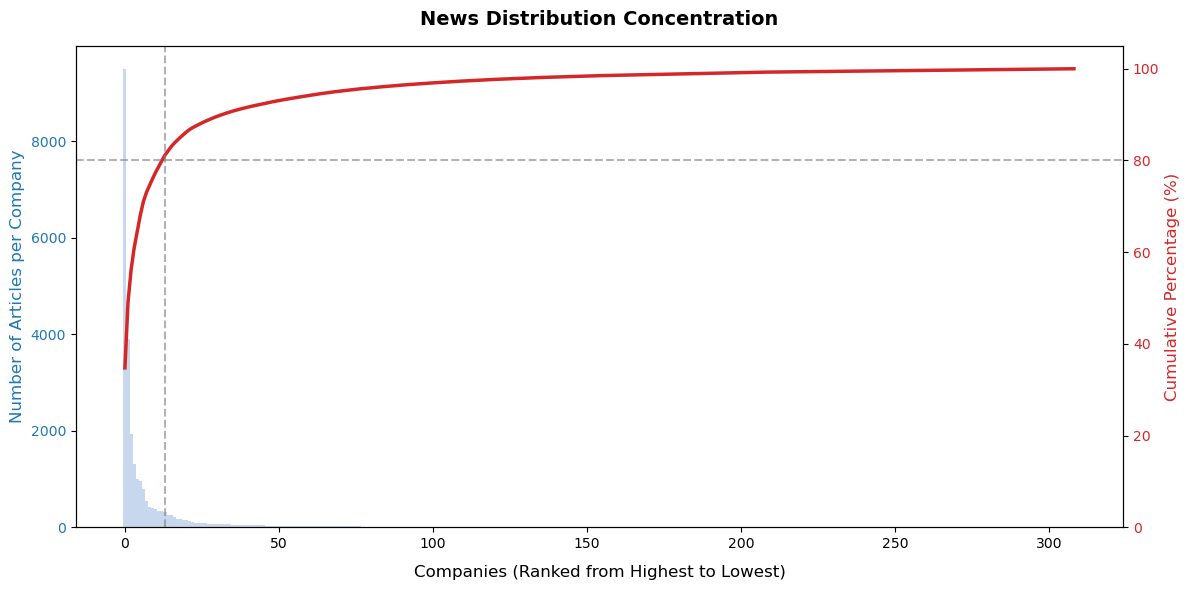

In [30]:
# Calculate cumulative percentage of all 309 companies
all_counts = main_mapped['company_search_name'].value_counts().sort_values(ascending=False)
cumulative_percentage = np.cumsum(all_counts.values) / all_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

# Bar chart
ax1.bar(range(len(all_counts)), all_counts.values, color='#aec7e8', alpha=0.7, width=1.0, label='Article Count')
ax1.set_ylabel('Number of Articles per Company', color='#1f77b4', fontsize=12)
ax1.set_xlabel('Companies (Ranked from Highest to Lowest)', fontsize=12, labelpad=10)
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Cumulative percentage curve
ax2 = ax1.twinx()
ax2.plot(range(len(all_counts)), cumulative_percentage, color='#d62728', linewidth=2.5, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.set_ylim(0, 105)

# 80% line
eighty_idx = np.where(cumulative_percentage >= 80)[0][0]
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.6)
ax2.axvline(x=eighty_idx, color='gray', linestyle='--', alpha=0.6)

plt.title("News Distribution Concentration", fontsize=14, fontweight='bold', pad=15)
print(f"The top {eighty_idx + 1} companies already capture 80% of the total news in the 10000 samples")

plt.tight_layout()
plt.show()

In [40]:
# Join companiesHouse & news
def join_coverage_table(sample_df: pd.DataFrame,
                     mapped_df: pd.DataFrame) -> pd.DataFrame:
    """
    Left-join match counts to the full sample. Unmatched companies get 0.
    """
    per_company = (
        mapped_df.groupby('company_search_name')
                 .size()
                 .reset_index(name='article_count')
    )

    out = sample_df.merge(
        per_company,
        left_on='search_name',
        right_on='company_search_name',
        how='left'
    )

    out['article_count'] = out['article_count'].fillna(0).astype(int)
    out['has_coverage'] = out['article_count'] > 0

    return out.drop(columns=['company_search_name'])

In [56]:
# use it to analyse
comp_Ngkg = join_coverage_table(main_sample, main_mapped)

print(f"Overall coverage: {comp_Ngkg['has_coverage'].mean():.1%}")
print(f" Matched: {comp_Ngkg['has_coverage'].sum()} / {len(comp_Ngkg)}")

def coverage_by_cate(company_gkg: pd.DataFrame, field: str):
    sector_cov = company_gkg.groupby(field).agg(
        n_companies=('CompanyNumber', 'count'),
        n_matched=('has_coverage', 'sum'),
        coverage_rate=('has_coverage', 'mean'),
        mean_articles=('article_count', 'mean'),
        sum_articles=('article_count', 'sum')
    ).sort_values('coverage_rate', ascending=False)

    print(sector_cov)

Overall coverage: 3.1%
 Matched: 309 / 10001


In [57]:
# break down by sector
print("\nBy sector:")
coverage_by_cate(comp_Ngkg, 'primary_sector')


By sector:
                                      n_companies  n_matched  coverage_rate  mean_articles  sum_articles
primary_sector                                                                                          
Fast growth & emerging sector                1076         45       0.041822      13.533457         14562
Technology, legal & professional             2461         89       0.036164       2.126778          5234
Healthcare                                    708         23       0.032486       0.703390           498
Public sector, education & charities          463         14       0.030238       0.462203           214
Manufacturing                                 677         20       0.029542       1.429838           968
Wholesale & Retail                           2148         63       0.029330       2.348231          5044
Real Estate                                  2341         54       0.023067       0.329774           772
Agriculture                                

In [58]:
# break down by sector
print("\nBy Accounts_AccountCategory:")
coverage_by_cate(comp_Ngkg, 'Accounts_AccountCategory')


By Accounts_AccountCategory:
                             n_companies  n_matched  coverage_rate  mean_articles  sum_articles
Accounts_AccountCategory                                                                       
GROUP                                 50          7       0.140000      10.440000           522
MEDIUM                                11          1       0.090909       0.181818             2
FULL                                  94          6       0.063830       1.872340           176
UNAUDITED ABRIDGED                   291         13       0.044674       0.831615           242
SMALL                                120          5       0.041667       8.666667          1040
DORMANT                             1179         48       0.040712       4.770144          5624
TOTAL EXEMPTION FULL                2429         78       0.032112       1.482915          3602
MICRO ENTITY                        3384         94       0.027778       1.343381          4546
NO ACCOUNT

### 3.5 Some conclusion

Out of 10,000 sampled UK companies, only about 3% had any GKG records in the past 3 months. Among the 309 matched companies, the top 14 alone account for 80% of all articles (see News Distribution Concentration chart).

By sector: Fast growth & emerging sector reaches 4.18%, Agriculture is almost absent (0.79%), and all other sectors fall in the 2–3% range. Even within each sector, a small number of companies contribute most of the articles.

By AccountCategory: broadly, larger companies have higher coverage. GROUP (consolidated accounts, largest scale) reaches 14% with the largest sum_articles.

A few outliers stand out:
- MEDIUM shows 9.09% coverage but only contains 11 companies and one company accounts for 9.09%. The sample is too small to draw conclusions. Same applies to AUDITED ABRIDGED (3 companies) and FILING EXEMPTION SUBSIDIARY (1 company).
- NO ACCOUNTS FILED has only 2.35% coverage, but its total article count reaches 11564. Some of these may be high-profile startups that have not yet filed accounts.
- DORMANT shows 4.07% coverage which is higher than MICRO ENTITY with a large total article count, which does not fit the literal meaning of "dormant". The reason has not been investigated in depth (possible name ambiguity, or shell companies under larger groups) and would need further validation.
- SMALL has only 5 matched companies, but they contributed 1040 articles. This is a head-of-distribution effect, not representative of SMALL overall.

Preliminary conclusions:

1. The current sample is not filtered to SMEs and BBs. GROUP-category companies typically represent large groups likely outside the project's target client base. It can therefore be inferred that GKG coverage for the actual target clients would be lower than the observed 3%. Once the team finalises the SME definition, this coverage should be re-evaluated.

2. Fast growth & emerging sector has noticeably higher coverage than other sectors (4.18% vs 2–3%) and a much larger sum_articles. Media features should primarily serve this sector.

3. AccountCategory reflects accounting type rather than strict physical company size, so there is some noise when using it as a size proxy.

4. The current coverage figures include uncertainty introduced by name ambiguity — some company names are common English words and may collide with unrelated entities in GKG. This has not been quantified in the EDA stage. More precise coverage figures would require an additional disambiguation step.